# BA820: Milestone II — Early Analysis & Insights
**Course:** BA820 - Unsupervised and Unstructured Machine Learning  
**Author:** Sanskruti Pawar  

**Dataset:** Hollywood Age Gaps (age_gaps.csv)  

---

## Table of Contents
### PART I: Problem Context & EDA
1. Dataset overview  
2. Temporal patterns  
3. Distribution shape & outliers  

### PART II: EDA & Preprocessing Updates
1. Sanity checks  
2. Decade construction and filtering decisions  
3. Decade-level feature engineering (for unsupervised methods)

### PART III: Analysis & Experiments (Unsupervised)
1. Method 1: Decade-level clustering of age-gap profiles (PCA + K-means)  
2. Method 2: Hierarchical clustering robustness check  

### PART IV: Findings, Interpretation & Next Steps


In [3]:
# Install + imports
!pip -q install seaborn>=0.12.0 scikit-learn>=1.2.0

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster


In [4]:
# Helper functions (lightweight & reusable)

def basic_overview(df, name="Dataset"):
    print(f"===== {name} =====")
    print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"Duplicate rows: {df.duplicated().sum():,}")
    print("\nMissing values (top 10):")
    miss = df.isna().sum().sort_values(ascending=False)
    display(miss.head(10))

def decade_from_year(y):
    return (y // 10) * 10

def quantiles_by_decade(df, q_list=(0.1,0.25,0.5,0.75,0.9)):
    out = (df.groupby("decade")["age_difference"]
             .quantile(q_list)
             .unstack()
             .reset_index())
    out.columns = ["decade"] + [f"q{int(q*100)}" for q in q_list]
    return out

def plot_quantile_trends(qdf):
    plt.figure(figsize=(8,4))
    for col in qdf.columns:
        if col != "decade":
            plt.plot(qdf["decade"], qdf[col], marker="o", label=col)
    plt.title("Age-gap quantiles by decade (distribution shift, not just mean)")
    plt.xlabel("Decade"); plt.ylabel("Age difference (years)")
    plt.legend()
    plt.show()


---
# PART I: Problem Context & EDA

## 1. Dataset overview
Each row is an **on-screen couple** in a movie, including:
- `release_year` (used to define film eras / decades)
- `age_difference` (absolute age gap between the two actors)
- actor ages and genders for later interpretation


In [23]:
# Load dataset
df = pd.read_csv("/content/age_gaps.csv")

basic_overview(df, "Hollywood Age Gaps")
display(df.head())


===== Hollywood Age Gaps =====
Shape: 1,155 rows × 13 columns
Duplicate rows: 0

Missing values (top 10):


,0
movie_name,0
release_year,0
director,0
age_difference,0
couple_number,0
actor_1_name,0
actor_2_name,0
character_1_gender,0
character_2_gender,0
actor_1_birthdate,0


,movie_name,release_year,director,age_difference,couple_number,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_birthdate,actor_2_birthdate,actor_1_age,actor_2_age
0,Harold and Maude,1971,Hal Ashby,52,1,Ruth Gordon,Bud Cort,woman,man,1896-10-30,1948-03-29,75,23
1,Venus,2006,Roger Michell,50,1,Peter O'Toole,Jodie Whittaker,man,woman,1932-08-02,1982-06-03,74,24
2,The Quiet American,2002,Phillip Noyce,49,1,Michael Caine,Do Thi Hai Yen,man,woman,1933-03-14,1982-10-01,69,20
3,The Big Lebowski,1998,Joel Coen,45,1,David Huddleston,Tara Reid,man,woman,1930-09-17,1975-11-08,68,23
4,Beginners,2010,Mike Mills,43,1,Christopher Plummer,Goran Visnjic,man,man,1929-12-13,1972-09-09,81,38


## 2. Temporal Patterns

**Research Question 1:**  
Do on-screen age gaps exhibit systematic differences across decades, and do these
patterns suggest the presence of distinct casting eras rather than a smooth trend over time?

#### What we check here:

- Whether average age gaps show clear trends or shifts over time
- Whether the full distribution of age gaps (spread, skewness, outliers) differs
  across decades, rather than only the mean
- Whether some decades exhibit substantially higher variability or extreme age gaps,
  suggesting looser or more permissive casting norms
- Whether patterns over time appear gradual or suggest distinct “eras” with
  different age-gap structures

These checks help determine whether decades can be meaningfully compared and whether
unsupervised methods are appropriate for identifying distinct casting regimes.

,release_year,count,mean,median,std
0,1935,2,13.000000,13.0,8.485281
1,1936,1,21.000000,21.0,NaN
2,1937,3,7.333333,9.0,5.686241
3,1939,1,12.000000,12.0,NaN
4,1940,3,11.333333,10.0,9.073772


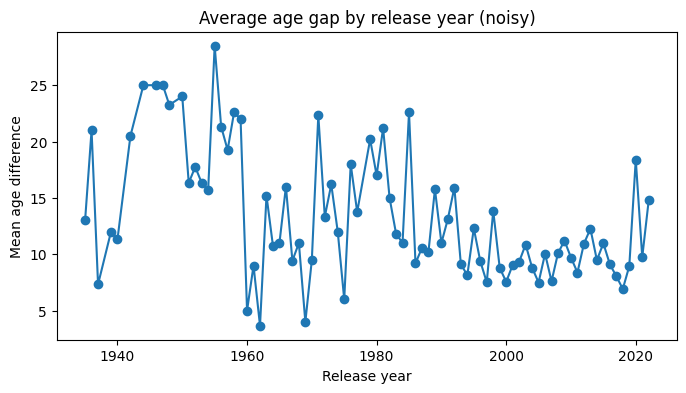

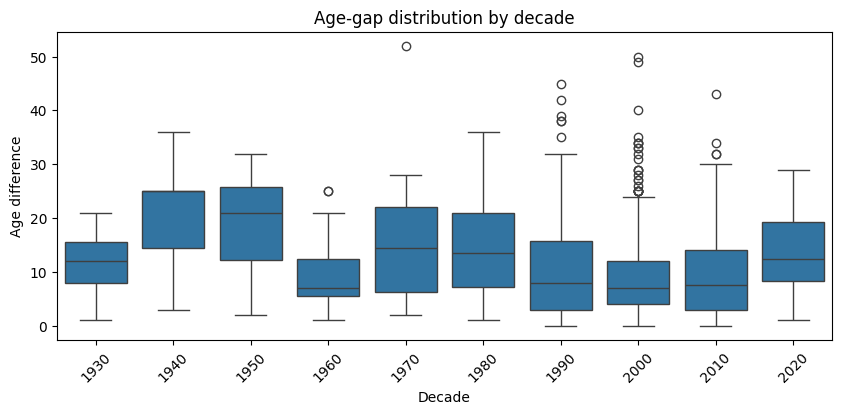

In [24]:
# Create decade
age["decade"] = age["release_year"].apply(decade_from_year)

# Summary by year (noisy but useful context)
year_stats = age.groupby("release_year")["age_difference"].agg(["count","mean","median","std"]).reset_index()
display(year_stats.head())

plt.figure(figsize=(8,4))
plt.plot(year_stats["release_year"], year_stats["mean"], marker="o")
plt.title("Average age gap by release year (noisy)")
plt.xlabel("Release year"); plt.ylabel("Mean age difference")
plt.show()

# Boxplots by decade (distribution shift)
plt.figure(figsize=(10,4))
sns.boxplot(data=age, x="decade", y="age_difference")
plt.title("Age-gap distribution by decade")
plt.xlabel("Decade"); plt.ylabel("Age difference")
plt.xticks(rotation=45)
plt.show()


### Interpretation

- Age gaps tend to be larger in earlier film decades and generally
  smaller in more recent decades.
- Decade level boxplots show a downward shift in the typical age gap over time,
  even though individual decades exhibit some variability.
- Year by year average age gaps are relatively noisy, particularly in earlier periods
  with fewer films, making decade level summaries more reliable for identifying
  broader temporal patterns.

**Research Question 2:**  
Do different gender pairings exhibit systematically different age-gap patterns?

Why it matters:  
- If age-gap distributions differ substantially across pairing types, these pairings may
  represent distinct casting archetypes rather than a single homogeneous pattern.
- Understanding pairing heterogeneity helps assess whether temporal patterns could be
  confounded by changes in the composition of relationship types over time.
- This also motivates potential future analyses that cluster films based on the mix of
  relationship archetypes they contain.


In [32]:
df['pairing_type'] = df['character_1_gender'] + "-" + df['character_2_gender']
df['pairing_type'].value_counts()


,count
pairing_type,
man-woman,929
woman-man,203
man-man,12
woman-woman,11


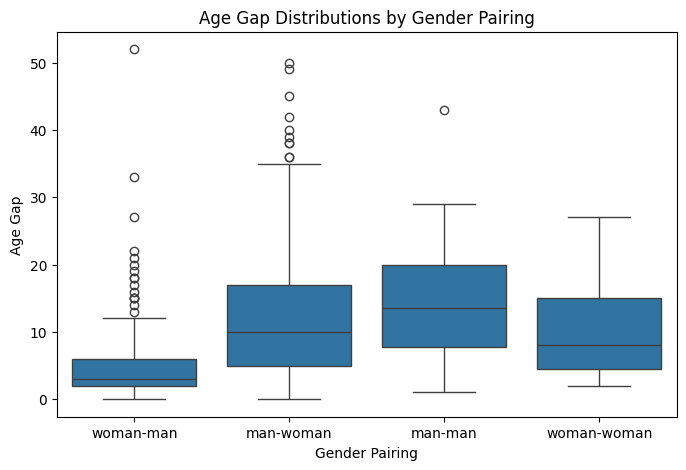

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='pairing_type', y='age_difference')
plt.title("Age Gap Distributions by Gender Pairing")
plt.xlabel("Gender Pairing")
plt.ylabel("Age Gap")
plt.show()


### Interpretation

- A gender pairing variable is created by combining the genders of the two characters.
- This allows comparison of age gap patterns across relationship types and helps assess
  whether temporal patterns may be influenced by pairing composition.
- Less frequent pairing types are considered when interpreting results.


**Research Question 3:**  
Are extreme age gaps primarily associated with cases where the older lead actor is
substantially older than their on-screen partner?

**Research Question 4:**  
Do certain movies or directors tend to exhibit consistently larger age gaps?

**What we check here:**
- The relationship between the older actor’s age and the observed age gap
- Whether a small subset of movies or directors accounts for unusually large gaps
- Whether films with multiple recorded couples contribute disproportionately to extreme values


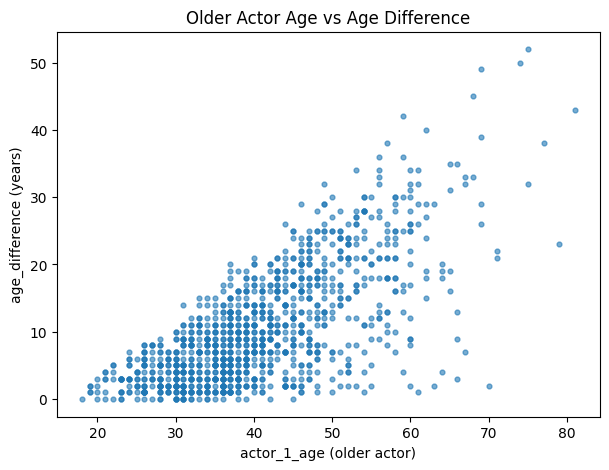

,director,n,avg_gap,med_gap
413,Roger Michell,3,30.000000,33.0
123,Eli Roth,3,22.000000,24.0
13,Alfred Hitchcock,7,21.000000,22.0
317,Michel Gondry,3,20.666667,15.0
202,Jerry Zucker,3,20.333333,16.0
504,Woody Allen,20,20.150000,18.5
217,John Glen,15,19.866667,21.0
171,Howard Hawks,4,19.250000,24.5
236,Jonathan Lynn,4,19.250000,19.0
209,Joel Coen,5,19.000000,11.0


,movie_name,n_couples
0,Love Actually,7
1,The Family Stone,6
2,Mona Lisa Smile,5
3,He's Just Not That Into You,5
4,A View to a Kill,5
5,A Star Is Born,4
6,Sex and the City,4
7,The Favourite,4
8,Boogie Nights,4
9,The Girl on the Train,4


,movie_name,release_year,director,actor_1_name,actor_1_age,actor_2_name,actor_2_age,pairing_type,age_difference
0,Harold and Maude,1971,Hal Ashby,Ruth Gordon,75,Bud Cort,23,woman-man,52
1,Venus,2006,Roger Michell,Peter O'Toole,74,Jodie Whittaker,24,man-woman,50
2,The Quiet American,2002,Phillip Noyce,Michael Caine,69,Do Thi Hai Yen,20,man-woman,49
3,The Big Lebowski,1998,Joel Coen,David Huddleston,68,Tara Reid,23,man-woman,45
4,Beginners,2010,Mike Mills,Christopher Plummer,81,Goran Visnjic,38,man-man,43
5,Poison Ivy,1992,Katt Shea,Tom Skerritt,59,Drew Barrymore,17,man-woman,42
6,Whatever Works,2009,Woody Allen,Larry David,62,Evan Rachel Wood,22,man-woman,40
7,Entrapment,1999,Jon Amiel,Sean Connery,69,Catherine Zeta-Jones,30,man-woman,39
8,Husbands and Wives,1992,Woody Allen,Woody Allen,57,Juliette Lewis,19,man-woman,38
9,Magnolia,1999,Paul Thomas Anderson,Jason Robards,77,Julianne Moore,39,man-woman,38


In [34]:
# --- 3. Casting Dynamics (RQ3 & RQ4) ---

# (If you haven't created pairing_type yet, run this once)
df["pairing_type"] = df["character_1_gender"] + "-" + df["character_2_gender"]

# RQ3: Relationship between older actor age and age gap
plt.figure(figsize=(7,5))
plt.scatter(df["actor_1_age"], df["age_difference"], s=12, alpha=0.6)
plt.title("Older Actor Age vs Age Difference")
plt.xlabel("actor_1_age (older actor)")
plt.ylabel("age_difference (years)")
plt.show()

# RQ4: Top directors by average age gap (filter out tiny sample sizes)
min_n = 3
dir_stats = (
    df.groupby("director")["age_difference"]
      .agg(n="size", avg_gap="mean", med_gap="median")
      .reset_index()
      .query("n >= @min_n")
      .sort_values("avg_gap", ascending=False)
)
display(dir_stats.head(15))

# Movies with multiple couples recorded (can influence overall patterns)
movie_couples = (
    df.groupby("movie_name")["couple_number"]
      .nunique()
      .sort_values(ascending=False)
)
multi = (
    movie_couples[movie_couples > 1]
    .head(15)
    .rename_axis("movie_name")
    .reset_index(name="n_couples")
)
display(multi)

# Show the biggest age gaps (sanity-check extremes)
top_gaps = (
    df.sort_values("age_difference", ascending=False)
      .head(15)[
          ["movie_name","release_year","director",
           "actor_1_name","actor_1_age","actor_2_name","actor_2_age",
           "pairing_type","age_difference"]
      ]
)
display(top_gaps)


### Interpretation

- Large age gaps mostly appear when the older lead actor is substantially older.
- A small number of movies or directors show higher average gaps, often based on
  limited observations.
- Movies with multiple couples contribute multiple rows and can disproportionately
  affect extreme values.


## 3. Distribution shape & outliers

**Why it matters:** Age gaps can be **right-skewed** with extreme outliers.  
If the data are skewed, then decade-level means may hide important changes in the *spread* and *tail behavior*.  
This motivates using decade-level features (median/variance/upper quantiles) rather than only averages.


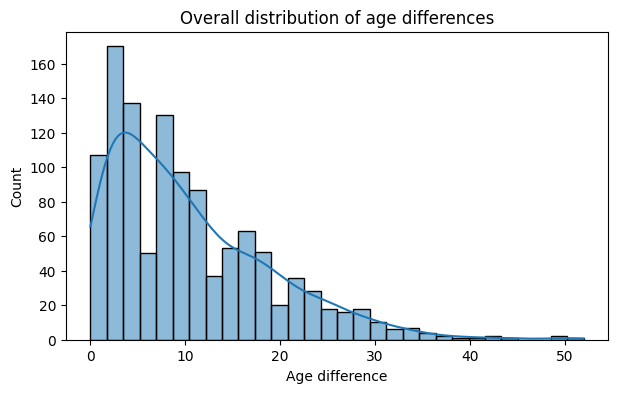

,decade,q10,q25,q50,q75,q90
0,1930,4.6,8.00,12.0,15.50,19.8
1,1940,7.3,14.50,25.0,25.00,25.0
2,1950,7.3,12.25,21.0,25.75,30.0
3,1960,3.0,5.50,7.0,12.50,18.6
4,1970,4.9,6.25,14.5,22.00,24.2
5,1980,3.0,7.25,13.5,21.00,28.1
6,1990,2.0,3.00,8.0,15.75,21.0
7,2000,1.0,4.00,7.0,12.00,20.0
8,2010,1.7,3.00,7.5,14.00,20.0
9,2020,4.5,8.25,12.5,19.25,23.5


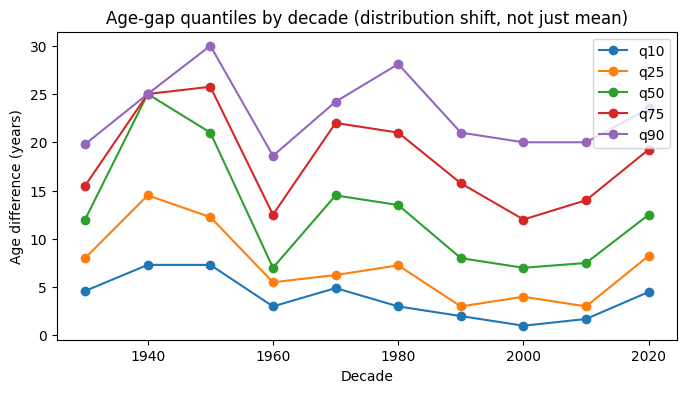

,movie_name,release_year,director,age_difference,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_age,actor_2_age
0,Harold and Maude,1971,Hal Ashby,52,Ruth Gordon,Bud Cort,woman,man,75,23
1,Venus,2006,Roger Michell,50,Peter O'Toole,Jodie Whittaker,man,woman,74,24
2,The Quiet American,2002,Phillip Noyce,49,Michael Caine,Do Thi Hai Yen,man,woman,69,20
3,The Big Lebowski,1998,Joel Coen,45,David Huddleston,Tara Reid,man,woman,68,23
4,Beginners,2010,Mike Mills,43,Christopher Plummer,Goran Visnjic,man,man,81,38
5,Poison Ivy,1992,Katt Shea,42,Tom Skerritt,Drew Barrymore,man,woman,59,17
6,Whatever Works,2009,Woody Allen,40,Larry David,Evan Rachel Wood,man,woman,62,22
7,Entrapment,1999,Jon Amiel,39,Sean Connery,Catherine Zeta-Jones,man,woman,69,30
8,Husbands and Wives,1992,Woody Allen,38,Woody Allen,Juliette Lewis,man,woman,57,19
9,Magnolia,1999,Paul Thomas Anderson,38,Jason Robards,Julianne Moore,man,woman,77,39


In [36]:
# Overall distribution
plt.figure(figsize=(7,4))
sns.histplot(age["age_difference"], bins=30, kde=True)
plt.title("Overall distribution of age differences")
plt.xlabel("Age difference"); plt.ylabel("Count")
plt.show()

# Quantile trends by decade (captures tails)
qdf = quantiles_by_decade(age, q_list=(0.1,0.25,0.5,0.75,0.9))
display(qdf)
plot_quantile_trends(qdf)

# Inspect extreme outliers (sanity check)
display(age.sort_values("age_difference", ascending=False).head(10)[
    ["movie_name","release_year","director","age_difference","actor_1_name","actor_2_name",
     "character_1_gender","character_2_gender","actor_1_age","actor_2_age"]
])


### Research Summary

- This EDA shows that age gap patterns vary across decades, supporting the investigation of
era level differences.
- It also reveals differences in age gap distributions
across gender pairings, indicating pairing heterogeneity.
- Examination of actor
ages in the EDA suggests that extreme age gaps are largely driven by substantially
older lead actors.
- Finally, it highlights variation across movies and directors,
as well as the influence of films with multiple couples, motivating further analysis of
casting dynamics.

## PART II: EDA & Preprocessing: Updates

**Milestone 1:**  
Initial EDA indicated that on-screen age gaps are not stable over time. Earlier
decades tend to show both larger typical gaps and greater dispersion, while later
decades exhibit more concentrated distributions, pointing to potential era-level
differences in casting practices.

Data consistency checks confirm that `actor_1_age` always corresponds to the older
(or same-age) actor and that `age_difference` is calculated as the difference between
the two actor ages, allowing age gaps to be interpreted consistently across films
and decades.

The age-gap distribution is highly right-skewed, with a small number of extreme
values. This motivates an emphasis on distributional summaries and variability
metrics, rather than relying solely on averages when analyzing temporal patterns.

**Milestone 2:**  
For this milestone, films are grouped into decade level units to smooth year by year noise and better reflect broader film eras.
Instead of filtering observations, film level age gaps are summarized into
decade level features capturing central tendency, spread, and upper tail behavior.
These features are standardized prior to unsupervised analysis to prevent scale
differences from driving results. Interpretation focuses on relative and
distributional differences across decades rather than isolated point estimates.


## 1. Sanity checks

Goal: ensure ages and age gaps are plausible and understand missingness before building decade-level profiles.

Before applying unsupervised methods, we perform basic sanity checks to ensure that
decade level features are well defined and not driven by data artifacts. In
particular, we verify sample sizes across decades and inspect the range of summary
statistics to confirm that no single decade is dominated by extremely small samples
or implausible values.


In [37]:
# Basic plausibility checks
print("Min/Max release_year:", age["release_year"].min(), age["release_year"].max())
print("Min/Max age_difference:", age["age_difference"].min(), age["age_difference"].max())
print("Min/Max actor_1_age:", age["actor_1_age"].min(), age["actor_1_age"].max())
print("Min/Max actor_2_age:", age["actor_2_age"].min(), age["actor_2_age"].max())

# Any negative or null values?
print("Negative age differences:", (age["age_difference"] < 0).sum())
print("Missing age_difference:", age["age_difference"].isna().sum())


Min/Max release_year: 1935 2022
Min/Max age_difference: 0 52
Min/Max actor_1_age: 18 81
Min/Max actor_2_age: 17 68
Negative age differences: 0
Missing age_difference: 0


### Interpretation

- Release years (1935–2022) and actor ages fall within plausible ranges.
- Age differences range from 0 to 52 years, with no negative or missing values.
- The data are consistent and suitable for decade level analysis.


## 2. Filtering decisions

At this stage, no decades or observations are removed from the analysis. All films with valid age information are retained to preserve the full temporal variation in age gap patterns across film eras. While extreme age gaps exist, they are kept in the data because they contribute to decade level variability, which is central to understanding differences in age gap structure over time.


In [38]:
# Decide a minimum sample size per decade
decade_counts = age["decade"].value_counts().sort_index()
display(decade_counts)

MIN_PER_DECADE = 15  # adjust if needed
valid_decades = decade_counts[decade_counts >= MIN_PER_DECADE].index

age_dec = age[age["decade"].isin(valid_decades)].copy()
print("Rows after decade min-count filter:", age_dec.shape[0])

# Optional: trim extreme tail (winsorize) for robustness (keeps rank order, caps extremes)
CAP_AT = age_dec["age_difference"].quantile(0.99)
age_dec["age_diff_cap99"] = age_dec["age_difference"].clip(upper=CAP_AT)

print("99th percentile cap used:", CAP_AT)


,count
decade,
1930,7
1940,12
1950,34
1960,35
1970,30
1980,50
1990,222
2000,409
2010,338


Rows after decade min-count filter: 1136
99th percentile cap used: 35.0


## 3. Decade level feature engineering

To compare decades as film eras, each decade is represented by a profile summarizing
the distribution of age gaps within that decade.

**Features used:**
- Mean and median age gap
- Standard deviation of age gaps
- 75th and 90th percentiles to capture upper-tail behavior
- Share of large age gaps (e.g., ≥ 20 years) as an interpretable marker of casting norms


In [45]:
# ----------------------------------------------------
# Build decade-level age-gap profiles
# ----------------------------------------------------

import numpy as np
import pandas as pd

# Work on a copy to avoid accidental overwrites
age_dec = df.copy()

# Create decade variable
age_dec["decade"] = (age_dec["release_year"] // 10) * 10

# Cap extreme age gaps at the 99th percentile for robustness
cap99 = age_dec["age_difference"].quantile(0.99)
age_dec["age_diff_cap99"] = age_dec["age_difference"].clip(upper=cap99)

print("99th percentile cap for age_difference:", cap99)

# Function to construct decade-level distribution profiles
def decade_profile(data, value_col="age_difference", large_gap=20):
    grouped = data.groupby("decade")[value_col]

    profile = pd.DataFrame({
        "n": grouped.size(),
        "mean": grouped.mean(),
        "median": grouped.median(),
        "std": grouped.std(ddof=1),
        "p75": grouped.quantile(0.75),
        "p90": grouped.quantile(0.90),
        "share_ge20": grouped.apply(lambda x: (x >= large_gap).mean())
    }).reset_index()

    return profile

# Build profiles using raw and capped age gaps
profile_raw = decade_profile(
    age_dec, value_col="age_difference", large_gap=20
)

profile_cap = decade_profile(
    age_dec, value_col="age_diff_cap99", large_gap=20
)

# Display raw profiles for transparency
display(profile_raw)

# Use capped version for clustering robustness
profile = profile_cap.copy()

# Select features for unsupervised analysis
features = ["mean", "median", "std", "p75", "p90", "share_ge20"]
X = profile[features].values


99th percentile cap for age_difference: 35.460000000000036


,decade,n,mean,median,std,p75,p90,share_ge20
0,1930,7,11.571429,12.0,6.876461,15.50,19.8,0.142857
1,1940,12,20.250000,25.0,9.440002,25.00,25.0,0.666667
2,1950,34,19.352941,21.0,8.495569,25.75,30.0,0.588235
3,1960,35,9.600000,7.0,6.376427,12.50,18.6,0.085714
4,1970,30,15.300000,14.5,10.488582,22.00,24.2,0.366667
5,1980,50,14.420000,13.5,9.084838,21.00,28.1,0.280000
6,1990,222,10.445946,8.0,8.924229,15.75,21.0,0.153153
7,2000,409,9.268949,7.0,8.030947,12.00,20.0,0.102689
8,2010,338,9.431953,7.5,7.676109,14.00,20.0,0.103550
9,2020,18,13.555556,12.5,8.008982,19.25,23.5,0.277778


---
# PART III: Analysis & Experiments (Unsupervised)

## Method 1: Decade level clustering of age gap regimes (PCA + K-means)

**Goal:** To assess whether film decades naturally group into distinct age gap regimes (e.g., higher gap, higher variance eras vs lower gap, more tightly distributed eras).

This directly supports the research question by testing whether changes across time are:
- gradual (no distinct clusters), or
- regime-like (clusters of decades with similar casting norms).


Explained variance ratio (PC1, PC2): [0.87153011 0.07949495]


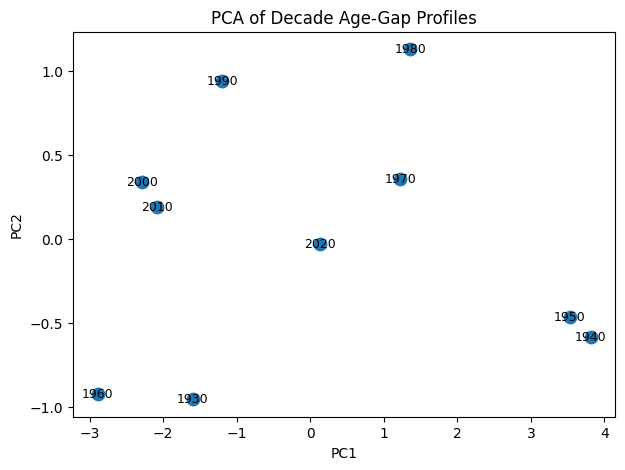

,K,inertia,silhouette
0,2,18.836894,0.491022
1,3,8.802066,0.479281
2,4,5.918772,0.388536
3,5,4.168798,0.298350
4,6,2.861348,0.181923


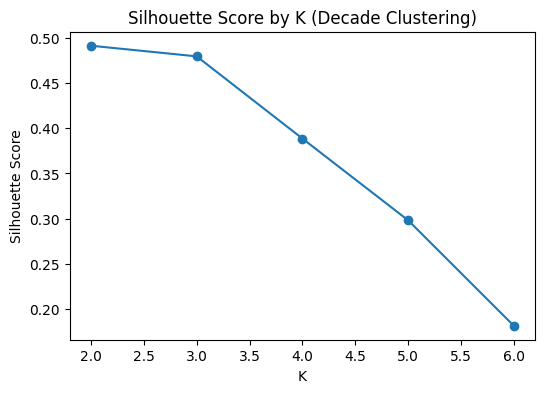

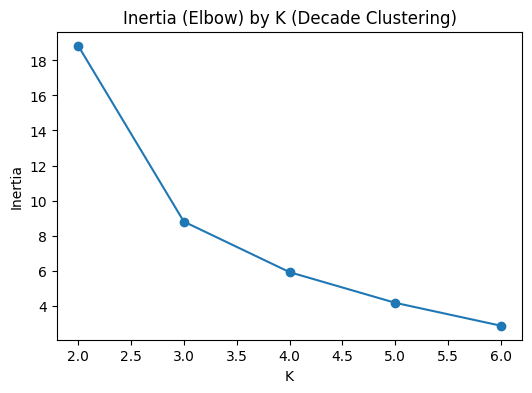

Selected K (highest silhouette): 2


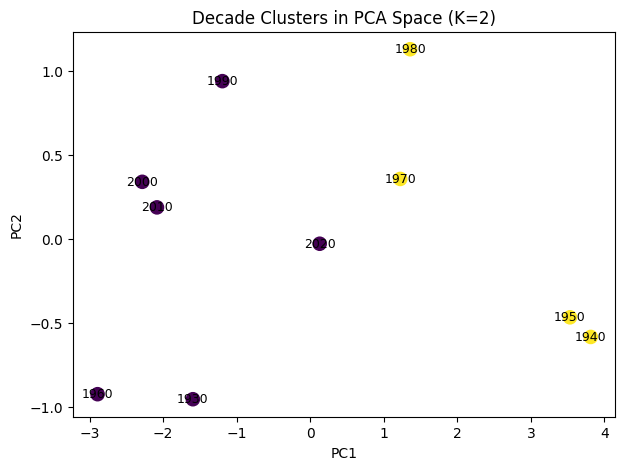

,decade,n,cluster
0,1930,7,0
1,1940,12,1
2,1950,34,1
3,1960,35,0
4,1970,30,1
5,1980,50,1
6,1990,222,0
7,2000,409,0
8,2010,338,0
9,2020,18,0


In [49]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Standardize features
# ----------------------------
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

# ----------------------------
# PCA for visualization
# ----------------------------
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(Xz)

print("Explained variance ratio (PC1, PC2):", pca.explained_variance_ratio_)

plt.figure(figsize=(7,5))
plt.scatter(Z[:, 0], Z[:, 1], s=80)

for i, d in enumerate(profile["decade"]):
    plt.text(Z[i, 0], Z[i, 1], str(d), fontsize=9, ha="center", va="center")

plt.title("PCA of Decade Age-Gap Profiles")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# ----------------------------
# Choose K: inertia + silhouette
# ----------------------------
ks = range(2, 7)
results = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(Xz)
    results.append({
        "K": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(Xz, labels)
    })

k_results = pd.DataFrame(results)
display(k_results)

plt.figure(figsize=(6,4))
plt.plot(k_results["K"], k_results["silhouette"], marker="o")
plt.title("Silhouette Score by K (Decade Clustering)")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(k_results["K"], k_results["inertia"], marker="o")
plt.title("Inertia (Elbow) by K (Decade Clustering)")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

# ----------------------------
# Fit final model
# ----------------------------
best_k = int(k_results.sort_values("silhouette", ascending=False).iloc[0]["K"])
print("Selected K (highest silhouette):", best_k)

final_km = KMeans(n_clusters=best_k, random_state=42, n_init=20)
profile["cluster"] = final_km.fit_predict(Xz)

# Visualize clusters in PCA space
plt.figure(figsize=(7,5))
plt.scatter(Z[:, 0], Z[:, 1], c=profile["cluster"], s=90)

for i, d in enumerate(profile["decade"]):
    plt.text(Z[i, 0], Z[i, 1], str(d), fontsize=9, ha="center", va="center")

plt.title(f"Decade Clusters in PCA Space (K={best_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

display(profile[["decade", "n", "cluster"]].sort_values("decade"))



**Note on selecting K:**  
Because the number of decades is small, silhouette scores can be sensitive to minor
changes in the data. Therefore, K is selected based on a combination of silhouette
scores and interpretability of the resulting clusters, rather than maximizing the
metric alone.


### Fit K-means with selected K and interpret clusters


,decade,n,mean,median,std,p75,p90,share_ge20,cluster_kmeans
0,1930,7,11.571429,12.0,6.876461,15.50,19.8,0.142857,0
1,1940,12,20.205000,25.0,9.359037,25.00,25.0,0.666667,2
2,1950,34,19.352941,21.0,8.495569,25.75,30.0,0.588235,2
3,1960,35,9.600000,7.0,6.376427,12.50,18.6,0.085714,0
4,1970,30,14.748667,14.5,8.790113,22.00,24.2,0.366667,1
5,1980,50,14.409200,13.5,9.058945,21.00,28.1,0.280000,1
6,1990,222,10.334685,8.0,8.562570,15.75,21.0,0.153153,0
7,2000,409,9.189193,7.0,7.699592,12.00,20.0,0.102689,0
8,2010,338,9.409645,7.5,7.588726,14.00,20.0,0.103550,0
9,2020,18,13.555556,12.5,8.008982,19.25,23.5,0.277778,1


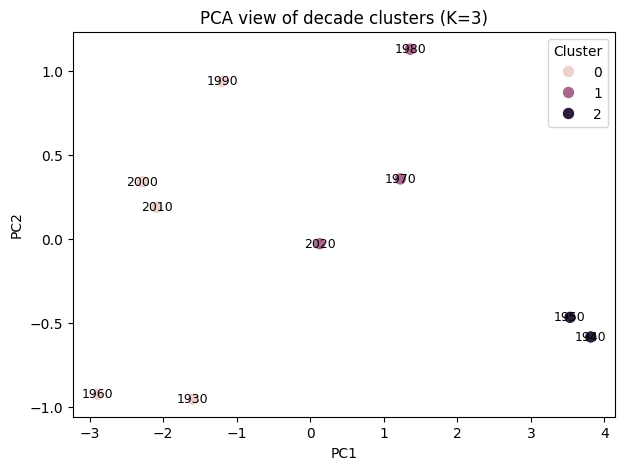

,cluster_kmeans,mean,median,std,p75,p90,share_ge20,n
0,0,10.020990,8.3,7.420755,13.950,19.880000,0.117593,202.200000
1,1,14.237807,13.5,8.619347,20.750,25.266667,0.308148,32.666667
2,2,19.778971,23.0,8.927303,25.375,27.500000,0.627451,23.000000


/tmp/ipython-input-1265430629.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,cluster_kmeans,mean,median,std,p75,p90,share_ge20,total_n
0,0,9.545143,7.421365,7.800517,13.533630,20.169733,0.113749,1011.0
1,1,14.356327,13.622449,8.783799,20.984694,26.061224,0.306122,98.0
2,2,19.575217,22.043478,8.720821,25.554348,28.695652,0.608696,46.0


In [54]:
# Select K (adjust if your silhouette suggests otherwise)
K = 3

km = KMeans(n_clusters=K, random_state=42, n_init=20)
profile["cluster_kmeans"] = km.fit_predict(Xz)

display(profile[["decade","n"] + features + ["cluster_kmeans"]].sort_values("decade"))

# Visualize clusters in PCA space
plt.figure(figsize=(7,5))
sns.scatterplot(x=Z[:,0], y=Z[:,1], hue=profile["cluster_kmeans"], s=80)

for i, d in enumerate(profile["decade"]):
    plt.text(Z[i,0], Z[i,1], str(d), fontsize=9, ha="center", va="center")

plt.title(f"PCA view of decade clusters (K={K})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

# Cluster summaries (unweighted)
cluster_summary = profile.groupby("cluster_kmeans")[features + ["n"]].mean().reset_index()
display(cluster_summary)

# Cluster summaries (weighted by decade sample size n)
def weighted_mean(group, col, wcol="n"):
    return np.average(group[col], weights=group[wcol])

weighted_summary = (
    profile.groupby("cluster_kmeans")
    .apply(
        lambda g: pd.Series(
            {f: weighted_mean(g, f) for f in features} | {"total_n": g["n"].sum()}
        )
    )
    .reset_index()
)
display(weighted_summary)


### Cluster Interpretation

- The clustering groups decades into distinct age gap regimes based on typical gaps, variability, and upper tail behavior.
- Clusters differ in their median/percentile levels and in the share of large gaps, suggesting that age gap norms vary structurally across film eras.
- Because decade sample sizes differ, cluster summaries are interpreted alongside `n` and (when used) weighted summaries.


### Method 2: Hierarchical Clustering (Robustness Check)

K-means clustering assumes roughly spherical clusters in feature space and requires pre specifying the number of clusters. As a robustness check, hierarchical clustering is applied to the same decade level age gap profiles. This merge based approach provides an alternative perspective on similarity across decades and helps assess whether the identified decade groupings are stable under a different clustering assumption.


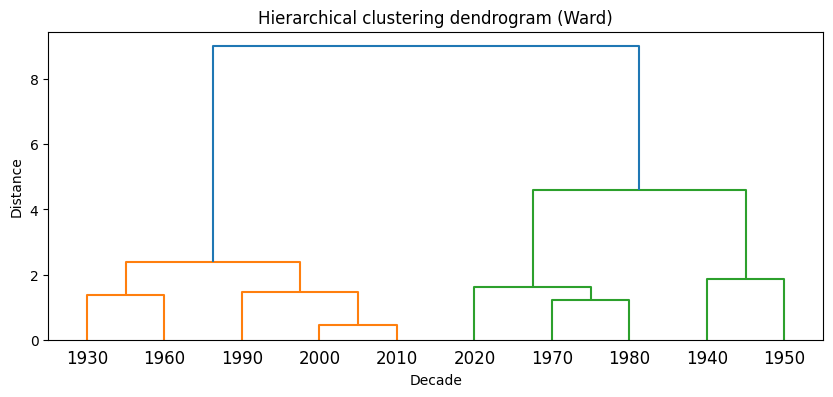

,decade,cluster_kmeans,cluster_hier
0,1930,0,0
1,1940,2,2
2,1950,2,2
3,1960,0,0
4,1970,1,1
5,1980,1,1
6,1990,0,0
7,2000,0,0
8,2010,0,0
9,2020,1,1


Exact decade-level label agreement (k-means vs hier): 1.0


In [55]:
# Hierarchical clustering (Ward linkage on standardized profiles)
Zlink = linkage(Xz, method="ward")

plt.figure(figsize=(10,4))
dendrogram(Zlink, labels=profile["decade"].astype(str).tolist())
plt.title("Hierarchical clustering dendrogram (Ward)")
plt.xlabel("Decade"); plt.ylabel("Distance")
plt.show()

# Cut the tree into K clusters (to compare with K-means)
profile["cluster_hier"] = fcluster(Zlink, t=K, criterion="maxclust") - 1  # make it 0..K-1
display(profile[["decade","cluster_kmeans","cluster_hier"]].sort_values("decade"))

# Agreement check (simple)
agreement = (profile["cluster_kmeans"] == profile["cluster_hier"]).mean()
print("Exact decade-level label agreement (k-means vs hier):", round(agreement, 3))


### Interpretation

- Hierarchical clustering groups decades based on similarity in age gap
  distributional profiles without assuming a specific cluster shape.
- The resulting groupings broadly align with those from K-means, despite some
  differences in exact assignments.
- This cross-method consistency suggests that the decade level patterns reflect
  underlying structure rather than artifacts of a single clustering approach.


### Synthesis Across Methods

Across both K-means and hierarchical clustering, decades exhibit consistent
groupings based on their age gap distributional profiles. While the two methods
differ in assumptions and exact cluster assignments, both reveal meaningful
structure across film eras rather than a smooth, homogeneous temporal trend.
Taken together, these results suggest that on screen age gap norms shift in
era level regimes, providing robust support for the presence of systematic
differences across decades.


---
#PART IV: Findings, Interpretation & Next Steps
###**Findings**:

Earlier film decades tend to exhibit larger typical on-screen age gaps and heavier upper tails, including a higher share of very large gaps (e.g., ≥20 years).

Decade-level clustering reveals distinct age-gap regimes rather than a smooth,
gradual trend over time, suggesting shifts in casting norms across eras.

Some decades appear transitional, combining features of both higher-gap and
lower-gap regimes, indicating periods of mixed or changing practices.

###**Interpretation**:

Taken together, these findings suggest that on-screen age-gap patterns differ
systematically across film eras. The presence of distinct decade-level regimes and
transitional periods implies that changes in casting norms may occur in shifts rather
than through steady, incremental change. These patterns are consistent across
multiple unsupervised methods, increasing confidence that they reflect meaningful
structural differences rather than noise.

###**Next Steps**:

Test sensitivity to alternative temporal groupings (e.g., 5-year bins) to assess
robustness of decade-level patterns.

Examine directional age gaps by gender (older man vs. older woman) to better
understand underlying casting mechanisms.

Incorporate additional stratification or controls (e.g., genre or director) to
separate era-level effects from creator-specific influences.


---